In [1]:
!pip install optuna scikit-learn matplotlib seaborn joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix
)
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
SEED = 42
np.random.seed(SEED)

SVM_TUNING_SUBSET = 5000
N_TRIALS_SVM = 20
MAX_ITER_FINAL = 3000

LABELS = [chr(i + ord('a')) for i in range(26)]

In [4]:
def load_data():
    train_files = [
        "emnist_lowercase_train_balanced.npz",
        "dataset_abjad_custom_train.npz"
    ]
    test_files = [
        "emnist_lowercase_test_balanced.npz",
        "dataset_abjad_custom_test.npz"
    ]

    def load_and_concat_npz(file_list, name):
        print(f"\n {name} Data...")
        X_list, y_list = [], []
        for file in file_list:
            try:
                data = np.load(file)
                keys = data.files
                if len(data[keys[0]].shape) > 1:
                    X_raw, y_raw = data[keys[0]], data[keys[1]]
                else:
                    X_raw, y_raw = data[keys[1]], data[keys[0]]
                X_list.append(X_raw)
                y_list.append(y_raw)
                print(f"   ✓ {file}: {len(X_raw):,} sampel")
            except FileNotFoundError:
                print(f"     File {file} tidak ditemukan")
        if not X_list:
            raise FileNotFoundError("Dataset tidak ditemukan")
        return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

    X_train_raw, y_train_raw = load_and_concat_npz(train_files, "TRAIN")
    X_test_raw, y_test_raw = load_and_concat_npz(test_files, "TEST")

    X_train = X_train_raw.astype(np.float32) / 255.0
    y_train = y_train_raw.astype(np.int64)
    X_test = X_test_raw.astype(np.float32) / 255.0
    y_test = y_test_raw.astype(np.int64)

    print(f"\n Dataset dimuat: Train={len(X_train):,}, Test={len(X_test):,}")
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()


 TRAIN Data...
   ✓ emnist_lowercase_train_balanced.npz: 49,296 sampel
   ✓ dataset_abjad_custom_train.npz: 6,240 sampel

 TEST Data...
   ✓ emnist_lowercase_test_balanced.npz: 8,242 sampel
   ✓ dataset_abjad_custom_test.npz: 260 sampel

 Dataset dimuat: Train=55,536, Test=8,502


Persentase Riil -> Train: 86.72% | Test: 13.28%
Grafik berhasil disimpan sebagai 'svm_visual_breakdown.png'


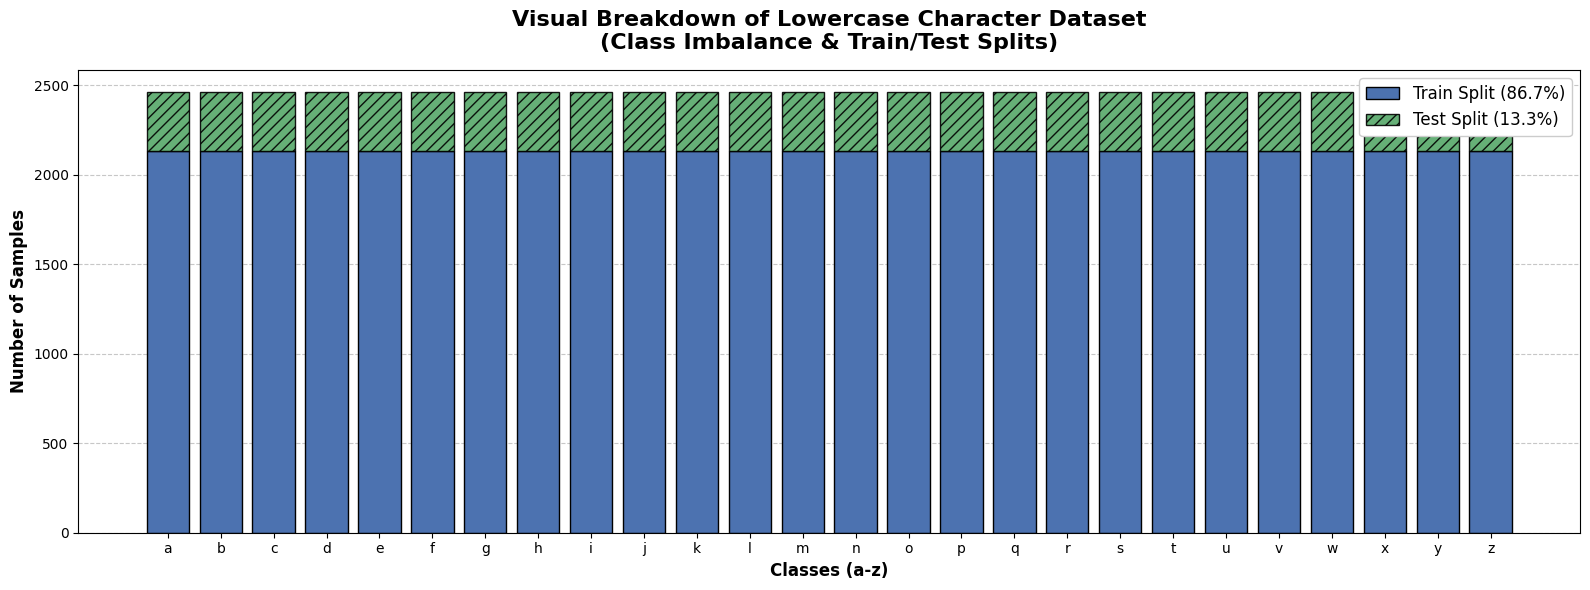


        RINGKASAN STATISTIK DATASET          
Total Kelas (Label)      : 26 Kelas (Abjad a-z)
Total Keseluruhan Sampel : 64,038 citra
  ├─ Data Pelatihan (Train): 55,536 citra (86.72%)
  └─ Data Pengujian (Test) : 8,502 citra (13.28%)
---------------------------------------------
Kelas Mayoritas Tertinggi: Huruf 'A' (2,463 sampel)
Kelas Minoritas Terendah : Huruf 'A' (2,463 sampel)
Rasio Imbalance (Max/Min): 1.00x lipat
---------------------------------------------
Rata-rata (Mean) / Kelas : 2,463 sampel
Nilai Tengah (Median)    : 2,463 sampel
Standar Deviasi          : 0.00



In [5]:
# Cell 4
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

# Memastikan indeks lengkap (0 sampai 25)
classes = np.arange(26)
train_values = [train_counts.get(i, 0) for i in classes]
test_values = [test_counts.get(i, 0) for i in classes]

# Label abjad
abjad_labels = [chr(i + ord('a')) for i in classes]

# GRAFIK
plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 6))

# Menghitung persentase
total_train_samples = sum(train_values)
total_test_samples = sum(test_values)
total_population = total_train_samples + total_test_samples

train_pct = (total_train_samples / total_population) * 100
test_pct = (total_test_samples / total_population) * 100

print(f"Persentase Riil -> Train: {train_pct:.2f}% | Test: {test_pct:.2f}%")

# Bar Train
p1 = ax.bar(abjad_labels, train_values, color='#4C72B0', edgecolor='black',
            label=f'Train Split ({train_pct:.1f}%)')

# Bar Test (stacked)
p2 = ax.bar(abjad_labels, test_values, bottom=train_values, color='#55A868',
            edgecolor='black', hatch='///', alpha=0.9, label=f'Test Split ({test_pct:.1f}%)')

# Kustomisasi
ax.set_title("Visual Breakdown of Lowercase Character Dataset\n(Class Imbalance & Train/Test Splits)",
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Classes (a-z)", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of Samples", fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_xticks(range(26))
ax.set_xticklabels(abjad_labels)
ax.legend(loc='upper right', fontsize=12, framealpha=1)

plt.tight_layout()
plt.savefig('svm_visual_breakdown.png', dpi=300, bbox_inches='tight')
print("Grafik berhasil disimpan sebagai 'svm_visual_breakdown.png'")
plt.show()

# STATISTIK DATASET
total_per_class = np.array(train_values) + np.array(test_values)
total_population = sum(total_per_class)

huruf_max = chr(np.argmax(total_per_class) + ord('a'))
huruf_min = chr(np.argmin(total_per_class) + ord('a'))

mean_samples = np.mean(total_per_class)
median_samples = np.median(total_per_class)
std_dev = np.std(total_per_class)
imbalance_ratio = max(total_per_class) / min(total_per_class)

print("\n=============================================")
print("        RINGKASAN STATISTIK DATASET          ")
print("=============================================")
print(f"Total Kelas (Label)      : 26 Kelas (Abjad a-z)")
print(f"Total Keseluruhan Sampel : {total_population:,} citra")
print(f"  ├─ Data Pelatihan (Train): {total_train_samples:,} citra ({train_pct:.2f}%)")
print(f"  └─ Data Pengujian (Test) : {total_test_samples:,} citra ({test_pct:.2f}%)")
print("-" * 45)
print(f"Kelas Mayoritas Tertinggi: Huruf '{huruf_max.upper()}' ({max(total_per_class):,} sampel)")
print(f"Kelas Minoritas Terendah : Huruf '{huruf_min.upper()}' ({min(total_per_class):,} sampel)")
print(f"Rasio Imbalance (Max/Min): {imbalance_ratio:.2f}x lipat")
print("-" * 45)
print(f"Rata-rata (Mean) / Kelas : {mean_samples:,.0f} sampel")
print(f"Nilai Tengah (Median)    : {median_samples:,.0f} sampel")
print(f"Standar Deviasi          : {std_dev:,.2f}")
print("=============================================\n")

In [6]:
# Cell 5
def preprocess(X_train, X_test):
    if len(X_train.shape) > 2:
        X_train = X_train.reshape(X_train.shape[0], -1)
        X_test = X_test.reshape(X_test.shape[0], -1)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f" Preprocessing selesai: {X_train_scaled.shape}")
    return X_train_scaled, X_test_scaled, scaler

X_train_scaled, X_test_scaled, scaler = preprocess(X_train, X_test)

 Preprocessing selesai: (55536, 784)


In [7]:
# Cell 6: Bayesian Optimization dengan Optuna

def svm_objective(trial, X_sub, y_sub):
    C = trial.suggest_float("C", 1e-2, 1e2, log=True)
    gamma = trial.suggest_float("gamma", 1e-4, 1e0, log=True)

    model = SVC(
        kernel="rbf",
        C=C,
        gamma=gamma,
        max_iter=2000,
        random_state=SEED
    )

    score = cross_val_score(
        model, X_sub, y_sub,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    ).mean()
    return score


def tune_svm(X_train_scaled, y_train):
    print("\n Bayesian Optimization untuk SVM (data seimbang)...")

    subset_size = min(SVM_TUNING_SUBSET, len(X_train_scaled))
    sss = StratifiedShuffleSplit(n_splits=1, train_size=subset_size, random_state=SEED)
    idx_sub, _ = next(sss.split(X_train_scaled, y_train))
    X_sub, y_sub = X_train_scaled[idx_sub], y_train[idx_sub]

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )

    study.optimize(
        lambda trial: svm_objective(trial, X_sub, y_sub),
        n_trials=N_TRIALS_SVM,
        show_progress_bar=True
    )

    print(f"\n Best params: C={study.best_params['C']:.4f}, gamma={study.best_params['gamma']:.6f}")
    print(f"   Best CV F1 (macro): {study.best_value:.4f}")
    return study.best_params

best_params = tune_svm(X_train_scaled, y_train)


 Bayesian Optimization untuk SVM (data seimbang)...


  0%|          | 0/20 [00:00<?, ?it/s]


 Best params: C=25.5036, gamma=0.000913
   Best CV F1 (macro): 0.8087


In [8]:
# Cell 7
print(f"\n Training SVM final (C={best_params['C']:.4f}, gamma={best_params['gamma']:.6f})...")

model = SVC(
    kernel="rbf",
    C=best_params["C"],
    gamma=best_params["gamma"],
    max_iter=MAX_ITER_FINAL,
    random_state=SEED
)

model.fit(X_train_scaled, y_train)
print("Training selesai")


 Training SVM final (C=25.5036, gamma=0.000913)...
Training selesai



 EVALUASI MODEL SVM (RBF Kernel) - Data Seimbang
   Accuracy  : 0.8859 (88.59%)
   Precision : 0.8871
   Recall    : 0.8859
   F1-Score  : 0.8861

 Classification Report:
              precision    recall  f1-score   support

           a       0.86      0.89      0.88       327
           b       0.93      0.94      0.94       327
           c       0.91      0.94      0.93       327
           d       0.91      0.93      0.92       327
           e       0.92      0.92      0.92       327
           f       0.87      0.90      0.88       327
           g       0.65      0.65      0.65       327
           h       0.92      0.91      0.91       327
           i       0.76      0.74      0.75       327
           j       0.90      0.86      0.88       327
           k       0.79      0.93      0.85       327
           l       0.80      0.82      0.81       327
           m       0.92      0.94      0.93       327
           n       0.92      0.90      0.91       327
           o     

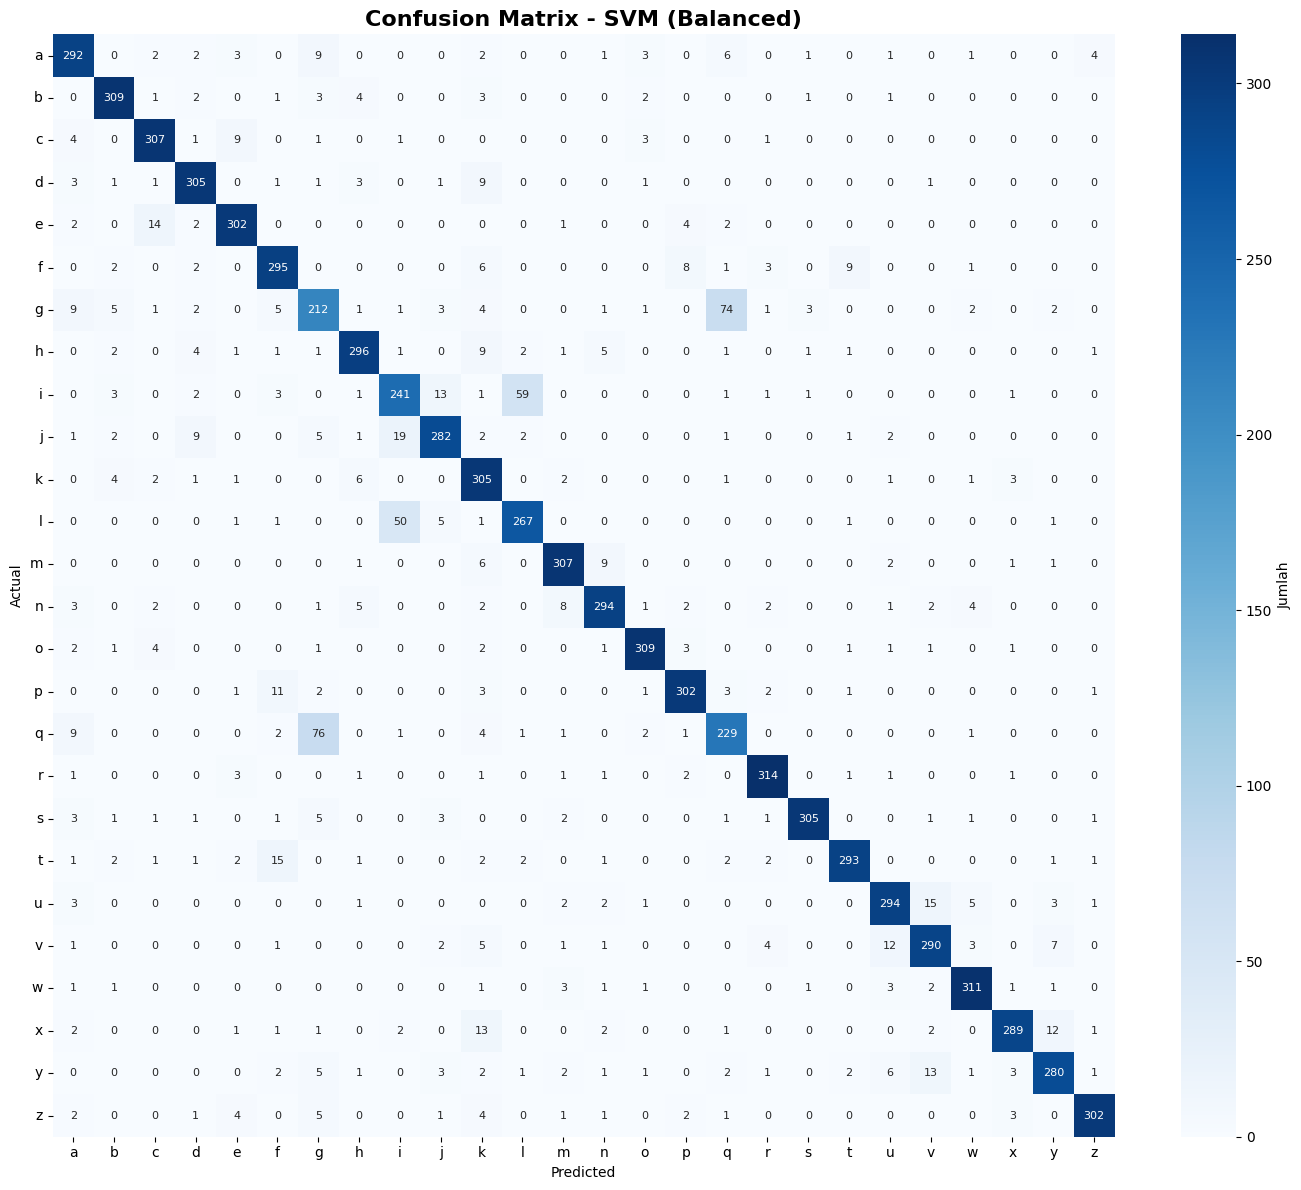

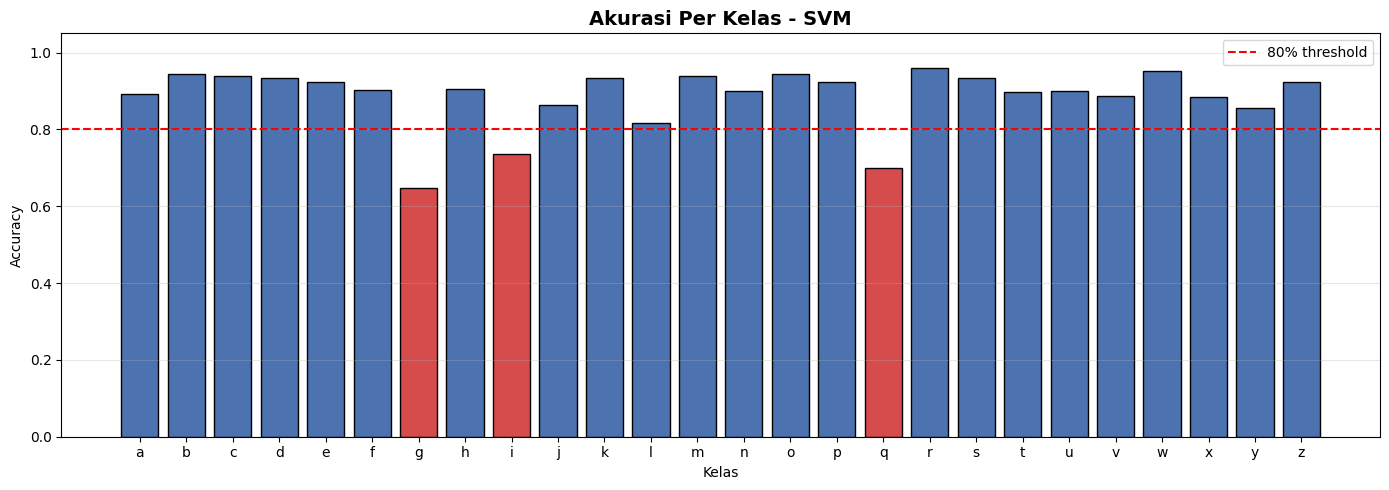


  Kelas dengan akurasi < 80%:
   'g': 64.8%
   'i': 73.7%
   'q': 70.0%


In [24]:
# Cell 8
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14,12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS,
                cbar_kws={'label':'Jumlah'}, annot_kws={'size':8})
    plt.title("Confusion Matrix - SVM (Balanced)", fontsize=16, fontweight='bold')
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=0); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('svm_confusion_matrix.png', dpi=300)
    plt.show()

def plot_per_class_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    plt.figure(figsize=(14,5))
    colors = ['#D64B4B' if acc < 0.8 else '#4C72B0' for acc in per_class_acc]
    plt.bar(LABELS, per_class_acc, color=colors, edgecolor='black')
    plt.axhline(0.8, color='red', linestyle='--', label='80% threshold')
    plt.title("Akurasi Per Kelas - SVM", fontsize=14, fontweight='bold')
    plt.xlabel("Kelas"); plt.ylabel("Accuracy")
    plt.ylim(0,1.05); plt.legend(); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('svm_per_class_accuracy.png', dpi=300)
    plt.show()

    low = [(LABELS[i], per_class_acc[i]) for i in range(26) if per_class_acc[i] < 0.8]
    if low:
        print("\n  Kelas dengan akurasi < 80%:")
        for label, acc in low:
            print(f"   '{label}': {acc*100:.1f}%")

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro')

print("\n EVALUASI MODEL SVM (RBF Kernel) - Data Seimbang")
print(f"   Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"   Precision : {prec:.4f}")
print(f"   Recall    : {rec:.4f}")
print(f"   F1-Score  : {f1:.4f}")
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=LABELS, zero_division=0))

plot_confusion_matrix(y_test, y_pred)
plot_per_class_accuracy(y_test, y_pred)

metrics = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

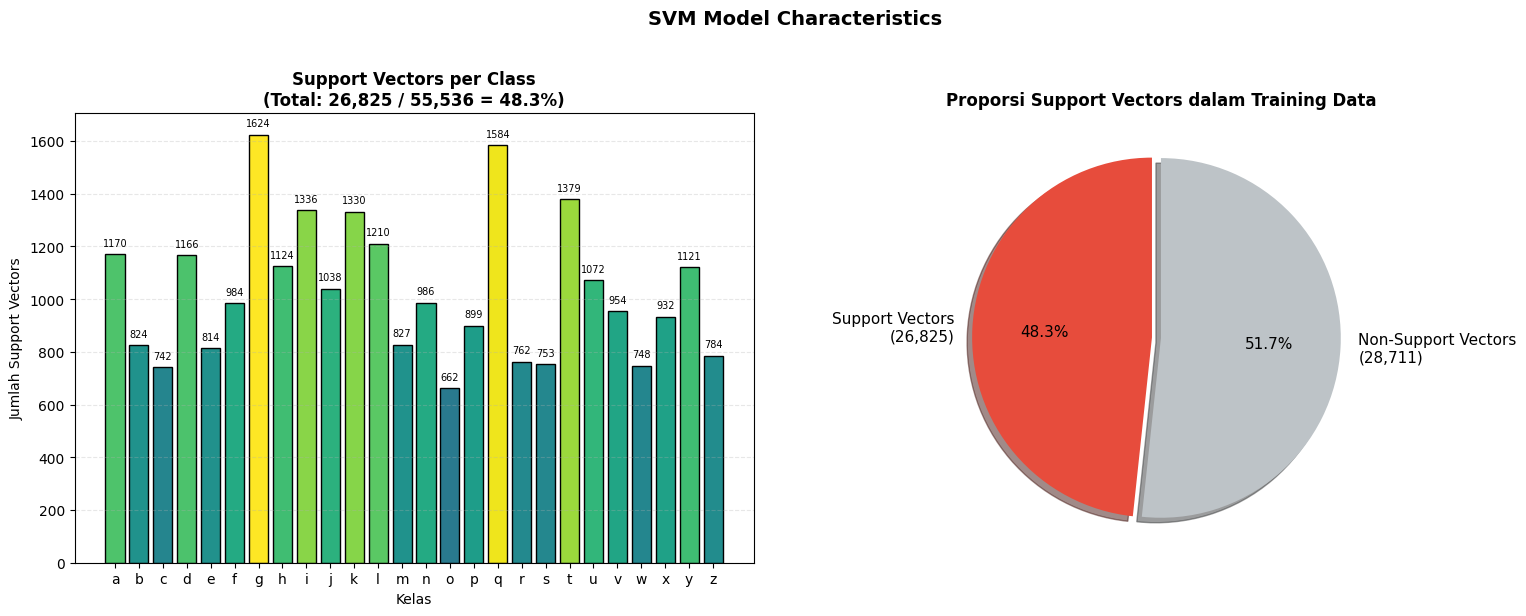


 Informasi Model SVM:
   Total data training    : 55,536
   Total support vectors  : 26,825 (48.30%)
   Rata-rata SV per kelas : 1032
   Parameter C            : 25.50361245526671
   Parameter gamma        : 0.0009125703046060933


In [25]:
def plot_svm_info(model, X_train_scaled, y_train):
    """Menampilkan informasi tentang support vectors"""
    n_support = model.n_support_
    support_vectors = model.support_vectors_
    n_total = len(X_train_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    support_per_class = np.array(model.n_support_)


    colors = plt.cm.viridis(support_per_class / max(support_per_class) if max(support_per_class) > 0 else np.ones(26))
    axes[0].bar(LABELS, support_per_class, color=colors, edgecolor='black')
    axes[0].set_title(f'Support Vectors per Class\n(Total: {len(support_vectors):,} / {n_total:,} = {len(support_vectors)/n_total*100:.1f}%)',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Kelas')
    axes[0].set_ylabel('Jumlah Support Vectors')
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')

    # Tambahkan nilai di atas bar
    for i, (label, count) in enumerate(zip(LABELS, support_per_class)):
        if count > 0:
            axes[0].text(i, count + max(support_per_class)*0.02, f'{int(count)}',
                        ha='center', fontsize=7)

    # Plot 2: Pie chart komposisi data
    sizes = [len(support_vectors), n_total - len(support_vectors)]
    labels_pie = [f'Support Vectors\n({len(support_vectors):,})',
                  f'Non-Support Vectors\n({n_total - len(support_vectors):,})']
    colors_pie = ['#e74c3c', '#bdc3c7']
    explode = (0.05, 0)

    axes[1].pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie,
                autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 11})
    axes[1].set_title('Proporsi Support Vectors dalam Training Data',
                      fontsize=12, fontweight='bold')

    plt.suptitle('SVM Model Characteristics', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('svm_model_info.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n Informasi Model SVM:")
    print(f"   Total data training    : {n_total:,}")
    print(f"   Total support vectors  : {len(support_vectors):,} ({len(support_vectors)/n_total*100:.2f}%)")
    print(f"   Rata-rata SV per kelas : {np.mean(support_per_class):.0f}")
    print(f"   Parameter C            : {model.C}")
    print(f"   Parameter gamma        : {model.gamma}")

plot_svm_info(model, X_train_scaled, y_train)

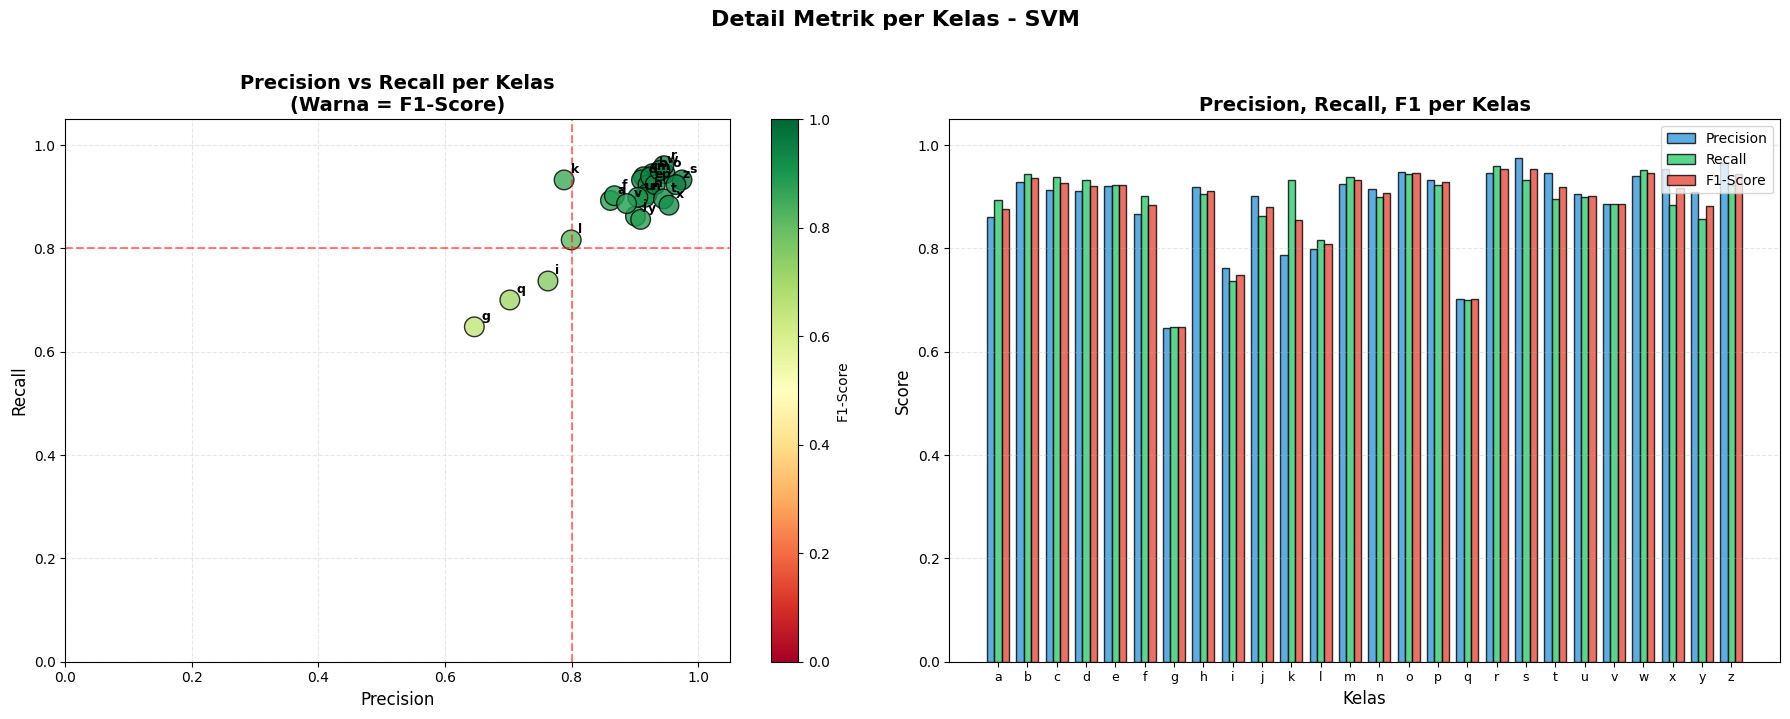


  Kelas dengan Precision < 80%:
   'g': Precision=0.646, Recall=0.648, F1=0.647
   'i': Precision=0.763, Recall=0.737, F1=0.750
   'k': Precision=0.788, Recall=0.933, F1=0.854
   'l': Precision=0.799, Recall=0.817, F1=0.808
   'q': Precision=0.702, Recall=0.700, F1=0.701

  Kelas dengan Recall < 80%:
   'g': Precision=0.646, Recall=0.648, F1=0.647
   'i': Precision=0.763, Recall=0.737, F1=0.750
   'q': Precision=0.702, Recall=0.700, F1=0.701


In [26]:
# Cell 8b: Precision-Recall per Kelas
from sklearn.metrics import precision_recall_fscore_support

def plot_precision_recall_per_class(y_true, y_pred):
    """Plot precision, recall, dan f1-score per kelas"""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, zero_division=0
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot 1: Precision vs Recall Scatter
    axes[0].scatter(precision, recall, c=f1, cmap='RdYlGn', s=200,
                    edgecolors='black', linewidth=1, alpha=0.8, vmin=0, vmax=1)

    # Tambahkan label untuk setiap titik
    for i, label in enumerate(LABELS):
        axes[0].annotate(label, (precision[i], recall[i]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=9, fontweight='bold')

    axes[0].set_xlabel('Precision', fontsize=12)
    axes[0].set_ylabel('Recall', fontsize=12)
    axes[0].set_title('Precision vs Recall per Kelas\n(Warna = F1-Score)',
                      fontsize=14, fontweight='bold')
    axes[0].set_xlim(0, 1.05)
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(alpha=0.3, linestyle='--')
    axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.5)
    axes[0].axvline(0.8, color='red', linestyle='--', alpha=0.5)

    # Tambahkan colorbar
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes[0])
    cbar.set_label('F1-Score', fontsize=10)

    # Plot 2: Grouped bar chart
    x = np.arange(26)
    width = 0.25

    axes[1].bar(x - width, precision, width, label='Precision',
                color='#3498db', edgecolor='black', alpha=0.8)
    axes[1].bar(x, recall, width, label='Recall',
                color='#2ecc71', edgecolor='black', alpha=0.8)
    axes[1].bar(x + width, f1, width, label='F1-Score',
                color='#e74c3c', edgecolor='black', alpha=0.8)

    axes[1].set_xlabel('Kelas', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title('Precision, Recall, F1 per Kelas', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(LABELS, fontsize=9)
    axes[1].legend(fontsize=10)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1].set_ylim(0, 1.05)

    plt.suptitle('Detail Metrik per Kelas - SVM', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('svm_precision_recall_per_class.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print kelas dengan precision/recall rendah
    print("\n  Kelas dengan Precision < 80%:")
    for i, (label, p) in enumerate(zip(LABELS, precision)):
        if p < 0.8:
            print(f"   '{label}': Precision={p:.3f}, Recall={recall[i]:.3f}, F1={f1[i]:.3f}")

    print("\n  Kelas dengan Recall < 80%:")
    for i, (label, r) in enumerate(zip(LABELS, recall)):
        if r < 0.8:
            print(f"   '{label}': Precision={precision[i]:.3f}, Recall={r:.3f}, F1={f1[i]:.3f}")

plot_precision_recall_per_class(y_test, y_pred)

In [27]:
model_data = {
    "model": model,
    "scaler": scaler,
    "metrics": metrics,
    "class_labels": LABELS
}
joblib.dump(model_data, "svm_model_balanced.pkl")
print("Model disimpan sebagai 'svm_model_balanced.pkl'")

Model disimpan sebagai 'svm_model_balanced.pkl'


In [21]:
# Cell 8f: Simpan metrics SVM ke JSON (untuk perbandingan nanti)
import json

cm = confusion_matrix(y_test, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

svm_metrics = {
    "model": "SVM (RBF Kernel)",
    "hyperparameters": {
        "C": float(model.C),
        "gamma": float(model.gamma)
    },
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1_score": float(f1),
    "per_class_accuracy": {LABELS[i]: float(per_class_acc[i]) for i in range(26)},
    "n_support_vectors": int(sum(model.n_support_)),
    "support_vectors_ratio": float(sum(model.n_support_) / len(X_train_scaled))
}

with open('svm_metrics.json', 'w') as f:
    json.dump(svm_metrics, f, indent=2)
print("Metrik SVM disimpan ke 'svm_metrics.json'")

Metrik SVM disimpan ke 'svm_metrics.json'
